In [15]:
'''
https://www.learnpytorch.io/04_pytorch_custom_datasets/


'''

'\nhttps://www.learnpytorch.io/04_pytorch_custom_datasets/\n\n\n'

In [16]:
'''

04. PyTorch 自定义数据集
In the last notebook, notebook 03, we looked at how to build computer vision models on an in-built dataset in PyTorch (FashionMNIST).
在上一个笔记本（笔记本 03）中，我们研究了如何在 PyTorch (FashionMNIST) 的内置数据集上构建计算机视觉模型。

The steps we took are similar across many different problems in machine learning.
对于机器学习中的许多不同问题，我们采取的步骤都是相似的。

Find a dataset, turn the dataset into numbers, build a model (or find an existing model) to find patterns in those numbers that can be used for prediction.
查找数据集，将数据集转换为数字，构建模型（或查找现有模型）以查找这些数字中可用于预测的模式。

PyTorch has many built-in datasets used for a wide number of machine learning benchmarks, however, you'll often want to use your own custom dataset.
PyTorch 有许多内置数据集，用于大量机器学习基准测试，但是，您通常希望使用自己的自定义数据集。

'''

"\n\n04. PyTorch 自定义数据集\nIn the last notebook, notebook 03, we looked at how to build computer vision models on an in-built dataset in PyTorch (FashionMNIST).\n在上一个笔记本（笔记本 03）中，我们研究了如何在 PyTorch (FashionMNIST) 的内置数据集上构建计算机视觉模型。\n\nThe steps we took are similar across many different problems in machine learning.\n对于机器学习中的许多不同问题，我们采取的步骤都是相似的。\n\nFind a dataset, turn the dataset into numbers, build a model (or find an existing model) to find patterns in those numbers that can be used for prediction.\n查找数据集，将数据集转换为数字，构建模型（或查找现有模型）以查找这些数字中可用于预测的模式。\n\nPyTorch has many built-in datasets used for a wide number of machine learning benchmarks, however, you'll often want to use your own custom dataset.\nPyTorch 有许多内置数据集，用于大量机器学习基准测试，但是，您通常希望使用自己的自定义数据集。\n\n"

In [17]:
'''

什么是自定义数据集？
A custom dataset is a collection of data relating to a specific problem you're working on.
自定义数据集是与您正在处理的特定问题相关的数据集合。

In essence, a custom dataset can be comprised of almost anything.
本质上，自定义数据集几乎可以由任何内容组成。

For example, if we were building a food image classification app like Nutrify, our custom dataset might be images of food.
例如，如果我们正在构建像 Nutrify 这样的食物图像分类应用程序，我们的自定义数据集可能是食物图像。

Or if we were trying to build a model to classify whether or not a text-based review on a website was positive or negative, our custom dataset might be examples of existing customer reviews and their ratings.
或者，如果我们尝试构建一个模型来对网站上基于文本的评论是正面还是负面进行分类，那么我们的自定义数据集可能是现有客户评论及其评级的示例。

Or if we were trying to build a sound classification app, our custom dataset might be sound samples alongside their sample labels.
或者，如果我们尝试构建声音分类应用程序，我们的自定义数据集可能是声音样本及其样本标签。

Or if we were trying to build a recommendation system for customers purchasing things on our website, our custom dataset might be examples of products other people have bought.
或者，如果我们试图为在我们网站上购买商品的客户构建推荐系统，我们的自定义数据集可能是其他人购买过的产品的示例。


PyTorch 包含许多现有函数，可加载  TorchVision 、 TorchText 、 TorchAudio 和 TorchRec 域库中的各种自定义数据集。


但有时这些现有的功能可能还不够。


在这种情况下，我们总是可以继承 torch.utils.data.Dataset 并根据我们的喜好自定义它。


我们要介绍的内容
We're going to be applying the PyTorch Workflow we covered in notebook 01 and notebook 02 to a computer vision problem.
我们将把笔记本 01和笔记本 02中介绍的 PyTorch 工作流程应用于计算机视觉问题。

But instead of using an in-built PyTorch dataset, we're going to be using our own dataset of pizza, steak and sushi images.
但我们将使用我们自己的披萨、牛排和寿司图像数据集，而不是使用内置的 PyTorch 数据集。

The goal will be to load these images and then build a model to train and predict on them.
目标是加载这些图像，然后构建模型来训练和预测它们。


我们要建造什么。我们将使用 torchvision.datasets 以及我们自己的自定义 Dataset 类来加载食物图像，
然后我们将构建一个 PyTorch 计算机视觉模型，希望能够对它们进行分类。

Specifically, we're going to cover:
具体来说，我们将涵盖：


0.导入PyTorch并设置与设备无关的代码     让我们加载 PyTorch，然后按照最佳实践将我们的代码设置为与设备无关。

1. 获取数据                          我们将使用我们自己的披萨、牛排和寿司图像的自定义数据集。

2. 与数据合而为一（数据准备）           在任何新的机器学习问题开始时，了解您正在使用的数据至关重要。在这里，
                                    我们将采取一些步骤来弄清楚我们拥有哪些数据。

3. 转换数据                          通常，您获得的数据不会 100% 准备好用于机器学习模型，
                                    在这里我们将了解可以采取的一些步骤来转换图像，以便它们准备好用于模型。


4. 使用ImageFolder加载数据(选项 1)     PyTorch 有许多针对常见数据类型的内置数据加载函数。如果我们的图像采用标准图像分类格式， 
                                    ImageFolder会很有帮助。

5. 使用自定义 Dataset 集加载图像数据    如果 PyTorch 没有内置函数来加载数据怎么办? 
                                    这是我们可以构建自己的torch.utils.data.Dataset的自定义子类的地方。    

6. 其他形式的变换（数据增强）           数据增强是扩展训练数据多样性的常用技术。在这里，我们将探索 torchvision 的一些内置数据增强功能。      

7. 模型0：没有数据增强的 TinyVGG       到这个阶段，我们将准备好数据，让我们构建一个能够拟合它的模型。我们还将创建一些训练和测试函数来训练和评估我们的模型。

8. 探索损失曲线                       损失曲线是了解模型如何随着时间的推移进行训练/改进的好方法。它们也是查看模型是否欠拟合或过拟合的好方法。

9. 模型 1：具有数据增强功能的 TinyVGG   到目前为止，我们已经尝试了一种没有 的模型，那么我们尝试一个带有数据增强的模型怎么样？

10. 比较模型结果                     让我们比较不同模型的损失曲线，看看哪个模型表现更好，并讨论一些提高性能的选项。

11. 对自定义图像进行预测              我们的模型接受了披萨、牛排和寿司图像数据集的训练。在本节中，我们将介绍如何使用经过训练的模型来预测现有数据集之外的图像。
'''

"\n\n什么是自定义数据集？\nA custom dataset is a collection of data relating to a specific problem you're working on.\n自定义数据集是与您正在处理的特定问题相关的数据集合。\n\nIn essence, a custom dataset can be comprised of almost anything.\n本质上，自定义数据集几乎可以由任何内容组成。\n\nFor example, if we were building a food image classification app like Nutrify, our custom dataset might be images of food.\n例如，如果我们正在构建像 Nutrify 这样的食物图像分类应用程序，我们的自定义数据集可能是食物图像。\n\nOr if we were trying to build a model to classify whether or not a text-based review on a website was positive or negative, our custom dataset might be examples of existing customer reviews and their ratings.\n或者，如果我们尝试构建一个模型来对网站上基于文本的评论是正面还是负面进行分类，那么我们的自定义数据集可能是现有客户评论及其评级的示例。\n\nOr if we were trying to build a sound classification app, our custom dataset might be sound samples alongside their sample labels.\n或者，如果我们尝试构建声音分类应用程序，我们的自定义数据集可能是声音样本及其样本标签。\n\nOr if we were trying to build a recommendation system for customers purchasing things on our website, our custom dataset might b

In [18]:
'''

0.导入PyTorch并设置与设备无关的代码




'''

import torch
from torch import nn

# Note: this notebook requires torch >= 1.10.0
print(torch.__version__)

# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


2.4.0+cu121


'cuda'

In [19]:
'''
1. 获取数据

首先我们需要一些数据。


就像任何优秀的烹饪节目一样，一些数据已经为我们准备好了。


我们要从小事做起。


因为我们还不打算训练最大的模型或使用最大的数据集。


机器学习是一个迭代过程，从小处开始，让某些东西发挥作用，并在必要时增加。


我们将使用的数据是 Food101 数据集的子集。


Food101 是流行的计算机视觉基准，因为它包含 101 种不同食物的 1000 张图像，
总共 101,000 张图像（75,750 个训练图像和 25,250 个测试图像）。


你能想到 101 种不同的食物吗？


你能想出一个计算机程序来对 101 种食物进行分类吗？

我可以。


机器学习模型！


具体来说，是我们在笔记本 03中介绍的 PyTorch 计算机视觉模型。


不过，我们不会从 101 类食物开始，而是从 3 类开始：披萨、牛排和寿司。

我们将从随机的 10% 开始（从小处开始，必要时增加），而不是每类 1,000 张图像。


如果您想查看数据的来源，可以查看以下资源：


原始 Food101 数据集和论文网站。

torchvision.datasets.Food101 - 我为此笔记本下载的数据版本。

extras/04_custom_data_creation.ipynb - 我用来格式化 Food101 数据集以用于此笔记本的笔记本。

data/pizza_steak_sushi.zip - 来自 Food101 的披萨、牛排和寿司图像的 zip 存档，使用上面链接的笔记本创建。

让我们编写一些代码来从 GitHub 下载格式化数据。


注意：我们即将使用的数据集已根据我们的用途进行了预先格式化。
但是，您通常必须针对您正在处理的任何问题来格式化自己的数据集。这是机器学习领域的常规做法。


'''

import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

        

data/pizza_steak_sushi directory exists.


In [7]:
'''

2. 与数据合而为一（数据准备）
Dataset downloaded! 数据集已下载！

Time to become one with it.
是时候与它合而为一了。

This is another important step before building a model.
这是构建模型之前的另一个重要步骤。

As Abraham Lossfunction said...
正如亚伯拉罕·损失函数所说……

If I had 8 hours to build a machine learning model, I'd spend the first 6 hours preparing my dataset.



数据准备至关重要。在构建模型之前，先与数据融为一体。问：我在这里想做什么？资料来源： @mrdbourke 推特。


检查数据并与之合而为一是什么？


在开始项目或构建任何类型的模型之前，了解您正在使用哪些数据非常重要。


在我们的例子中，我们有标准图像分类格式的披萨、牛排和寿司的图像。


图像分类格式在以特定类名标题的单独目录中包含单独的图像类。


例如，所有pizza图像都包含在 pizza/ 目录中。

这种格式在许多不同的图像分类基准中都很流行，包括ImageNet （最流行的计算机视觉基准数据集）。

您可以在下面看到存储格式的示例，图像数量是任意的。

pizza_steak_sushi/ <- overall dataset folder
    train/ <- training images
        pizza/ <- class name as folder name
            image01.jpeg
            image02.jpeg
            ...
        steak/
            image24.jpeg
            image25.jpeg
            ...
        sushi/
            image37.jpeg
            ...
    test/ <- testing images
        pizza/
            image101.jpeg
            image102.jpeg
            ...
        steak/
            image154.jpeg
            image155.jpeg
            ...
        sushi/
            image167.jpeg
            ...
'''

"\n\n2. 与数据合而为一（数据准备）\nDataset downloaded! 数据集已下载！\n\nTime to become one with it.\n是时候与它合而为一了。\n\nThis is another important step before building a model.\n这是构建模型之前的另一个重要步骤。\n\nAs Abraham Lossfunction said...\n正如亚伯拉罕·损失函数所说……\n\nIf I had 8 hours to build a machine learning model, I'd spend the first 6 hours preparing my dataset.\n\n\n\n数据准备至关重要。在构建模型之前，先与数据融为一体。问：我在这里想做什么？资料来源： @mrdbourke 推特。\n\n\n检查数据并与之合而为一是什么？\n\n\n在开始项目或构建任何类型的模型之前，了解您正在使用哪些数据非常重要。\n\n\n在我们的例子中，我们有标准图像分类格式的披萨、牛排和寿司的图像。\n\n\n图像分类格式在以特定类名标题的单独目录中包含单独的图像类。\n\n\n例如，所有pizza图像都包含在pizza/目录中。\n\n这种格式在许多不同的图像分类基准中都很流行，包括ImageNet （最流行的计算机视觉基准数据集）。\n\n您可以在下面看到存储格式的示例，图像数量是任意的。\n\npizza_steak_sushi/ <- overall dataset folder\n    train/ <- training images\n        pizza/ <- class name as folder name\n            image01.jpeg\n            image02.jpeg\n            ...\n        steak/\n            image24.jpeg\n            image25.jpeg\n            ...\n        sushi/\n            image37.jpeg\n            ...\n    test/ <- testi

In [8]:
'''
目标是采用此数据存储结构并将其转换为可与 PyTorch 一起使用的数据集。


注意：您使用的数据结构会根据您正在处理的问题而有所不同。
但前提仍然是：与数据融为一体，然后找到一种方法将其最好地转换为与 PyTorch 兼容的数据集。


我们可以通过编写一个小帮助函数来检查数据目录中的内容，以遍历每个子目录并计算存在的文件数。


为此，我们将使用 Python 内置的os.walk() 。
'''

import os
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)}\t images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0	 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0	 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 19	 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31	 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 25	 images in 'data/pizza_steak_sushi/test/pizza'.
There are 3 directories and 0	 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 75	 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72	 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 78	 images in 'data/pizza_steak_sushi/train/pizza'.


In [20]:
'''

出色的！
看起来每个训练类有大约 75 个图像，每个测试类有 25 个图像。

这应该足以开始了。

请记住，这些图像是原始 Food101 数据集的子集。1

您可以在数据创建笔记本中查看它们是如何创建的。

当我们这样做时，让我们设置我们的训练和测试路径。

'''


# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir



(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Random image path: data/pizza_steak_sushi/test/pizza/2236338.jpg
Image class: pizza
Image height: 512
Image width: 512


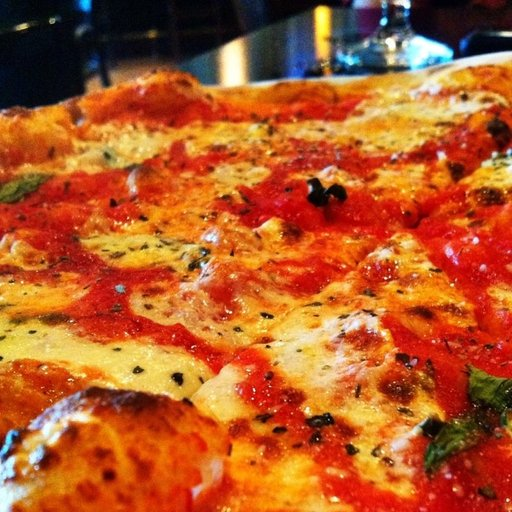

In [22]:
'''
2.1 Visualize an image 2.1 可视化图像
Okay, we've seen how our directory structure is formatted.
好的，我们已经了解了目录结构的格式。

Now in the spirit of the data explorer, it's time to visualize, visualize, visualize!
现在，本着数据探索者的精神，是时候可视化、可视化、可视化了！

Let's write some code to:
让我们编写一些代码：

Get all of the image paths using pathlib.Path.glob() to find all of the files ending in .jpg.
使用pathlib.Path.glob()获取所有图像路径，以查找所有以.jpg结尾的文件。

Pick a random image path using Python's random.choice().
使用 Python 的random.choice()选择随机图像路径。

Get the image class name using pathlib.Path.parent.stem.
使用pathlib.Path.parent.stem获取图像类名称。

And since we're working with images, we'll open the random image path using PIL.Image.open() (PIL stands for Python Image Library).
由于我们正在处理图像，因此我们将使用PIL.Image.open()打开随机图像路径（PIL 代表 Python 图像库）。

We'll then show the image and print some metadata.
然后我们将显示图像并打印一些元数据。

'''

import random
from PIL import Image

# Set seed
random.seed(42) # <- try changing this and see what happens

# 1. Get all image paths (* means "any combination")
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Get random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img






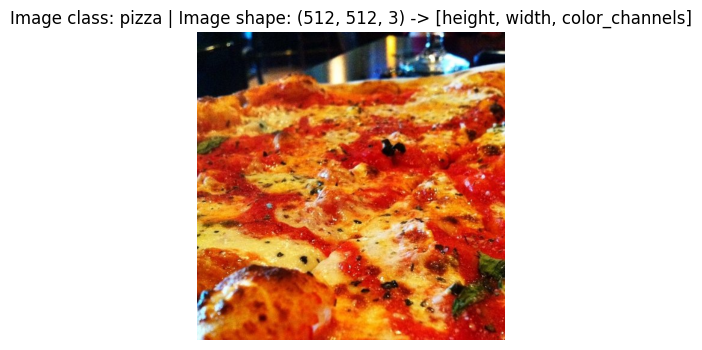

In [27]:
'''
我们可以对matplotlib.pyplot.imshow()执行相同的操作，只不过我们必须首先将图像转换为 NumPy 数组。

'''

import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(5, 4))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

# plt.axis(True);

In [28]:
'''

3. Transforming data 3. 转换数据

现在，如果我们想将图像数据加载到 PyTorch 中怎么办？
在将图像数据与 PyTorch 一起使用之前，我们需要：

将其转换为张量（图像的数字表示）。

将其转换为torch.utils.data.Dataset ，然后转换为torch.utils.data.DataLoader ，我们简称为 Dataset 和 DataLoader 。


PyTorch 有几种不同类型的预构建数据集和数据集加载器，具体取决于您正在处理的问题。


Problem space       Pre-built Datasets and Functions
问题空间             预构建的数据集和函数

Vision 图片          torchvision.datasets
Audio 声音的         torchaudio.datasets
Text 文本            torchtext.datasets
推荐系统              torchrec.datasets


由于我们正在处理视觉问题，因此我们将查看 torchvision.datasets 用于数据加载功能，以及 torchvision.transforms 用于准备数据。


让我们导入一些基础库。

'''

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms



In [29]:
'''
 
3.1 使用torchvision.transforms转换数据 

我们有图像文件夹，但在将它们与 PyTorch 一起使用之前，我们需要将它们转换为张量。
 
我们可以做到这一点的方法之一是使用torchvision.transforms模块。

torchvision.transforms 包含许多预构建的方法， 用于格式化图像、将它们转换为张量，
甚至操纵它们以实现数据增强（改变数据以使模型更难学习的做法，我们稍后会看到）目的。

为了获得 torchvision.transforms 的经验， 让我们编写一系列转换步骤：


使用 transforms.Resize()调整图像大小（从大约 512x512 到 64x64 ， 与 CNN Expander 网站上的图像形状相同）。

使用以下命令在水平方向上随机翻转图像 transforms.RandomHorizontalFlip() 
（这可以被认为是数据增强的一种形式，因为它会人为地改变我们的图像数据）。

使用 transforms.ToTensor() 将我们的图像从 PIL 图像转换为 PyTorch 张量。

我们可以使用以下命令编译所有这些步骤 torchvision.transforms.Compose() 。



'''

# Write transform for image
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0 
])



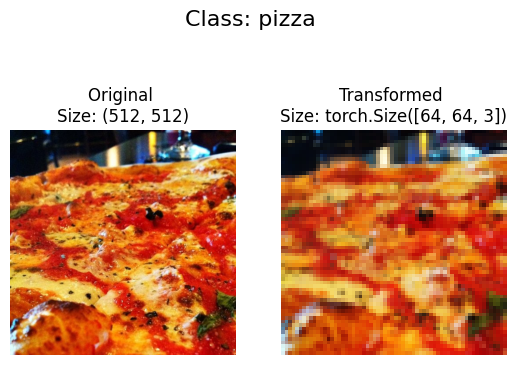

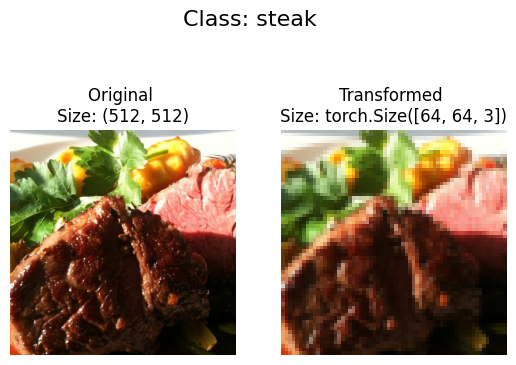

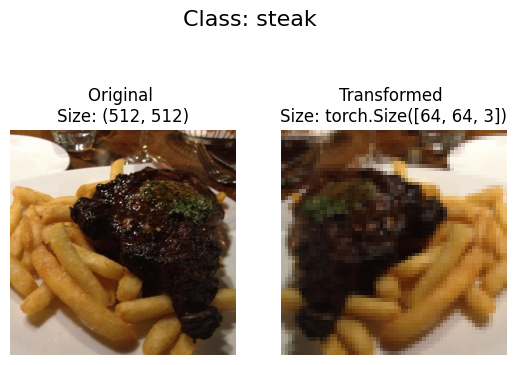

In [33]:
'''
现在我们已经有了变换的组合，让我们编写一个函数来在各种图像上尝试它们。




'''


def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n) # 随机选取 3 张图片
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            # ax[0].figure(figsize=(5, 4))
            ax[0].imshow(f) 
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib 
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            # suhao transform 获得一张 PIL.Image 经过变形，转化为 tensor
            transformed_image = transform(f).permute(1, 2, 0) 
            # ax[1].figure(figsize=(5, 4))
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")

            # fig.figure(figsize=(5, 4))
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_path_list, 
                        transform=data_transform, 
                        n=3)




In [ ]:
'''

我们现在有了一种使用 torchvision.transforms 将图像转换为张量的方法。

如果需要，我们还会操纵它们的大小和方向（某些模型更喜欢不同大小和形状的图像）。

一般来说，图像的形状越大，模型可以恢复的信息就越多。

例如，尺寸为 [256, 256, 3] 的图像的像素比尺寸为 [64, 64, 3] 的图像多 16 倍（ (256*256*3)/(64*64*3)=16 ） 。

然而，代价是更多的像素需要更多的计算。



'''

In [34]:
'''

4. 选项 1  使用ImageFolder加载图像数据

好吧，是时候将我们的图像数据转换为能够与 PyTorch 一起使用的Dataset集了。


由于我们的数据采用标准图像分类格式，因此我们可以使用该类 torchvision.datasets.ImageFolder 。


我们可以向它传递目标图像目录的文件路径以及我们想要对图像执行的一系列转换。

让我们在数据文件夹 train_dir 和 test_dir 上进行测试，传入 transform = data_transform 将图像转换为张量



'''

# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=data_transform, # transforms to perform on data (images)
                                  target_transform=None) # transforms to perform on labels (if necessary)

test_data = datasets.ImageFolder(root=test_dir, 
                                 transform=data_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [38]:
'''
看起来 PyTorch 已经注册了我们的Dataset 。
让我们通过检查classes和class_to_idx属性以及训练集和测试集的长度来检查它们。



'''

# Get class names as a list
class_names = train_data.classes
print(class_names)

# Can also get class names as a dict
class_dict = train_data.class_to_idx
print(class_dict)

['pizza', 'steak', 'sushi']
{'pizza': 0, 'steak': 1, 'sushi': 2}


In [ ]:
'''

'''

In [12]:
'''

'''


'\n\n'

In [13]:
'''

'''

'\n\n'

In [14]:
'''

'''

'\n\n'

In [ ]:
'''

'''